In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def calc_woe_iv(df, feature, target, bins, method = 'quantile'):
    if method == 'quantile':
        df['bin'] = pd.qcut(df[feature], bins, duplicates = 'drop')
    else:
        df['bin'] = pd.cut(df[feature], bins, duplicates = 'drop')

    grouped = df.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'events']
    grouped['non_events'] = grouped['total'] - grouped['events']
    
    grouped['%events'] = grouped['events'] / grouped['events'].sum()
    grouped['%non_events'] = grouped['non_events'] / grouped['non_events'].sum()

    grouped['WoE'] = np.log((grouped['%non_events'] + 1e-6) / (grouped['%events'] + 1e-6))

    grouped['IV'] = (grouped['%non_events'] - grouped['%events']) * grouped['WoE']
    IV = grouped['IV'].sum()

    return grouped.reset_index(), IV

def plot_woe(grouped, feature_name):
    plt.figure(figsize=(8,5))
    sns.barplot(x=grouped['bin'].astype(str), y=grouped['WoE'], color="skyblue")
    plt.xticks(rotation=45)
    plt.title(f"WoE Plot for {feature_name}")
    plt.xlabel("Bins")
    plt.ylabel("Weight of Evidence (WoE)")
    plt.axhline(0, color="red", linestyle="--")
    plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.049409182184764235
              bin  total  events  non_events   %events  %non_events       WoE  \
0  (11.999, 23.0]  52530    3528       49002  0.147658     0.213250  0.367561   
1    (23.0, 25.0]  36696    3009       33687  0.125936     0.146601  0.151936   
2    (25.0, 27.0]  45168    4034       41134  0.168836     0.179009  0.058509   
3    (27.0, 30.0]  46008    4724       41284  0.197715     0.179662 -0.095748   
4    (30.0, 33.0]  31697    3559       28138  0.148956     0.122453 -0.195924   
5    (33.0, 98.0]  41581    5039       36542  0.210899     0.159026 -0.282311   

         IV  
0  0.024109  
1  0.003140  
2  0.000595  
3  0.001729  
4  0.005193  
5  0.014644  


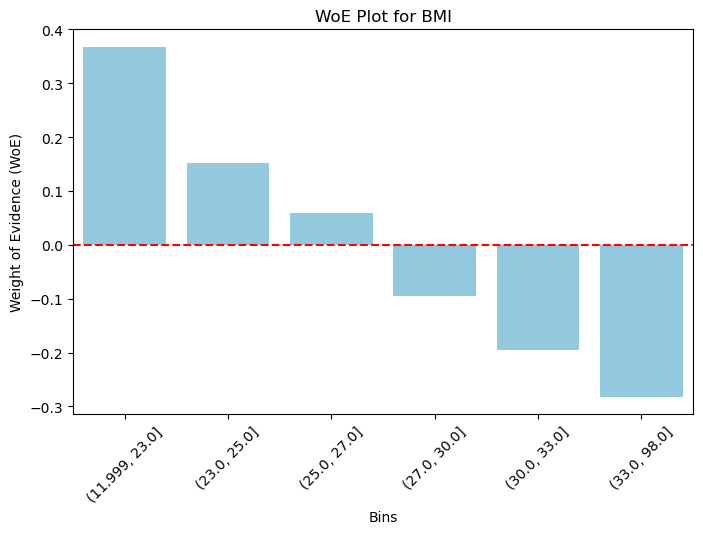

In [21]:
df = pd.read_csv('D:\ML\Heart Disease\heart_disease.csv')

woe_table, iv_bmi = calc_woe_iv(df, feature="bmi", target="result", bins=6, method="quantile")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "BMI")

In [11]:
df['bin'].unique()

[(33.0, 98.0], (23.0, 25.0], (27.0, 30.0], (25.0, 27.0], (30.0, 33.0], (11.999, 23.0]]
Categories (6, interval[float64, right]): [(11.999, 23.0] < (23.0, 25.0] < (25.0, 27.0] < (27.0, 30.0] < (30.0, 33.0] < (33.0, 98.0]]

In [36]:
df['bmi:11_23'] = np.where((df['bmi'] > 11) & (df['bmi'] <= 23), 1, 0)
df['bmi:23_25'] = np.where((df['bmi'] > 23) & (df['bmi'] <= 25), 1, 0)
df['bmi:25_27'] = np.where((df['bmi'] > 25) & (df['bmi'] <= 27), 1, 0)
df['bmi:27_30'] = np.where((df['bmi'] > 27) & (df['bmi'] <= 30), 1, 0)
df['bmi:30_33'] = np.where((df['bmi'] > 30) & (df['bmi'] <= 33), 1, 0)
df['bmi:33_98'] = np.where((df['bmi'] > 33) & (df['bmi'] <= 98), 1, 0)

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.7666265085263344
            bin  total  events  non_events   %events  %non_events       WoE  \
0  (0.996, 1.8]  45299    1016       44283  0.042523     0.192713  1.511142   
1    (1.8, 2.6]  89084    4128       84956  0.172770     0.369716  0.760770   
2    (2.6, 3.4]  75646    7914       67732  0.331227     0.294760 -0.116641   
3    (3.4, 4.2]  31570    6728       24842  0.281589     0.108109 -0.957304   
4    (4.2, 5.0]  12081    4107        7974  0.171891     0.034702 -1.600051   

         IV  
0  0.226959  
1  0.149831  
2  0.004254  
3  0.166073  
4  0.219510  


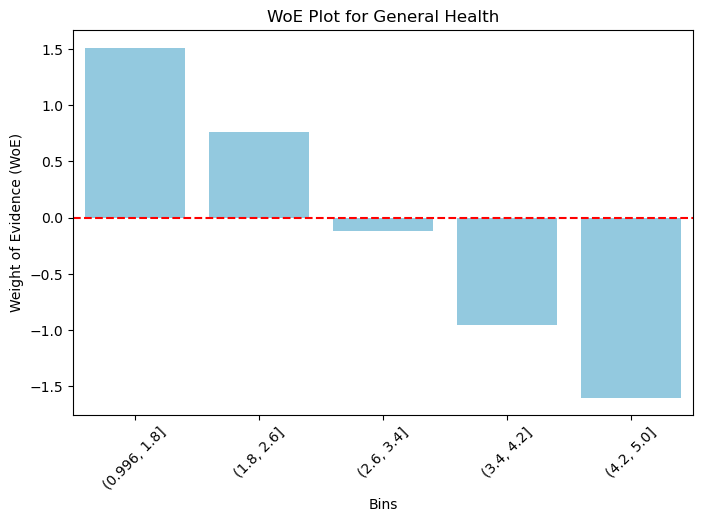

In [52]:
woe_table, iv_bmi = calc_woe_iv(df, feature="general_health", target="result", bins=5, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "General Health")

In [18]:
df['general_health'].unique()

array([5, 3, 2, 4, 1])

In [23]:
df['general_health:1'] = np.where(df['general_health'] == 1, 1, 0)
df['general_health:2'] = np.where(df['general_health'] == 2, 1, 0)
df['general_health:3'] = np.where(df['general_health'] == 3, 1, 0)
df['general_health:4'] = np.where(df['general_health'] == 4, 1, 0)
df['general_health:5'] = np.where(df['general_health'] == 5, 1, 0)

In [24]:
df['mental_health'].unique()

array([15,  0, 30,  2, 14, 28,  7, 20,  3, 10,  1,  5, 17,  4, 19,  6, 12,
       25, 27, 21, 22,  8, 29, 24,  9, 16, 18, 23, 13, 26, 11])

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.3035585017646719
            bin   total  events  non_events   %events  %non_events       WoE  \
0  (-0.03, 3.0]  194699   13167      181532  0.551082     0.790001  0.360150   
1    (3.0, 6.0]   13494    1666       11828  0.069728     0.051474 -0.303518   
2    (6.0, 9.0]    5526     665        4861  0.027832     0.021154 -0.274344   
3   (9.0, 12.0]    6233    1033        5200  0.043234     0.022630 -0.647355   
4  (12.0, 15.0]    7571    1318        6253  0.055163     0.027212 -0.706603   
5  (15.0, 18.0]     360      68         292  0.002846     0.001271 -0.805886   
6  (18.0, 21.0]    3958     780        3178  0.032646     0.013830 -0.858812   
7  (21.0, 24.0]     198      38         160  0.001590     0.000696 -0.825173   
8  (24.0, 27.0]    1504     337        1167  0.014105     0.005079 -1.021333   
9  (27.0, 30.0]   20137    4821       15316  0.201775     0.066653 -1.107641   

         IV  
0  0.086047  
1  0.005540  
2  0.001832  
3  0.013339 

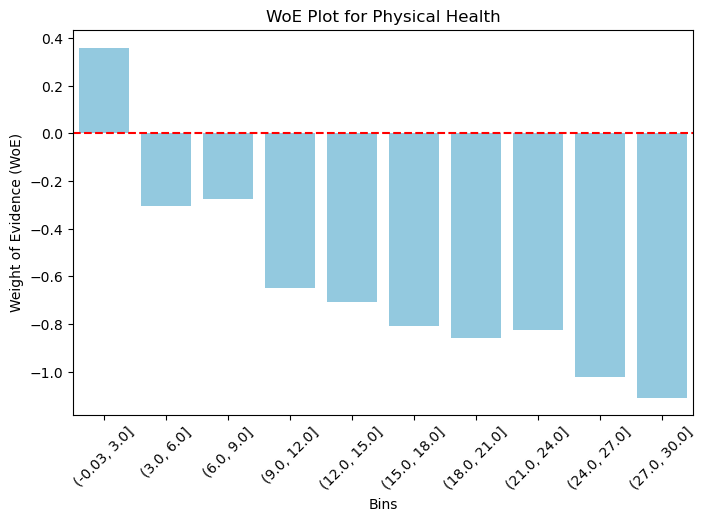

In [54]:
woe_table, iv_bmi = calc_woe_iv(df, feature="physical_health", target="result", bins=10, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "Physical Health")

In [37]:
df['physical_health:0_3'] =  np.where((df['physical_health'] >= 0) & (df['physical_health'] <= 3), 1, 0)
df['physical_health:3_9'] =  np.where((df['physical_health'] > 3) & (df['physical_health'] <= 9), 1, 0)
df['physical_health:9_15'] =  np.where((df['physical_health'] > 9) & (df['physical_health'] <= 15), 1, 0)
df['physical_health:15_24'] =  np.where((df['physical_health'] > 15) & (df['physical_health'] <= 24), 1, 0)
df['physical_health:24_30'] =  np.where((df['physical_health'] > 24) & (df['physical_health'] <= 30), 1, 0)

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.04283339923130476
            bin   total  events  non_events   %events  %non_events       WoE  \
0  (-0.03, 3.0]  204653   17851      186802  0.747123     0.812935  0.084422   
1    (3.0, 6.0]   13807    1251       12556  0.052358     0.054642  0.042687   
2    (6.0, 9.0]    3830     338        3492  0.014146     0.015197  0.071612   
3   (9.0, 12.0]    6812     753        6059  0.031516     0.026368 -0.178326   
4  (12.0, 15.0]    6713     857        5856  0.035868     0.025484 -0.341772   
5  (15.0, 18.0]     239      34         205  0.001423     0.000892 -0.466500   
6  (18.0, 21.0]    3607     512        3095  0.021429     0.013469 -0.464321   
7  (21.0, 24.0]     134      18         116  0.000753     0.000505 -0.399696   
8  (24.0, 27.0]    1312     199        1113  0.008329     0.004844 -0.541971   
9  (27.0, 30.0]   12573    2080       10493  0.087055     0.045664 -0.645216   

         IV  
0  0.005556  
1  0.000097  
2  0.000075  
3  0.000918

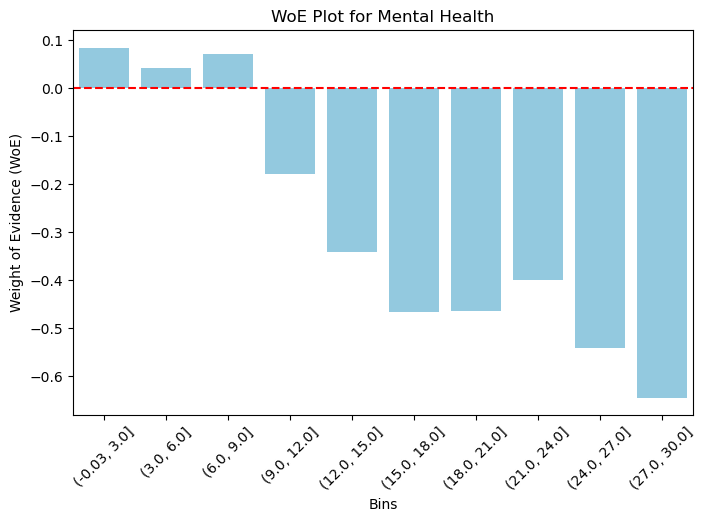

In [55]:
woe_table, iv_bmi = calc_woe_iv(df, feature="mental_health", target="result", bins=10, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "Mental Health")

In [38]:
df['mental_health:0_9'] =  np.where((df['mental_health'] >= 0) & (df['mental_health'] <= 9), 1, 0)
df['mental_health:9_12'] =  np.where((df['mental_health'] > 9) & (df['mental_health'] <= 12), 1, 0)
df['mental_health:12_15'] =  np.where((df['mental_health'] > 12) & (df['mental_health'] <= 15), 1, 0)
df['mental_health:15_21'] =  np.where((df['mental_health'] > 15) & (df['mental_health'] <= 21), 1, 0)
df['mental_health:21_24'] =  np.where((df['mental_health'] > 21) & (df['mental_health'] <= 24), 1, 0)
df['mental_health:24_27'] =  np.where((df['mental_health'] > 24) & (df['mental_health'] <= 27), 1, 0)
df['mental_health:27_30'] =  np.where((df['mental_health'] > 27) & (df['mental_health'] <= 30), 1, 0)

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.7707870632609741
            bin  total  events  non_events   %events  %non_events       WoE  \
0  (0.988, 2.5]  13298      83       13215  0.003474     0.057510  2.806430   
1    (2.5, 4.0]  24946     319       24627  0.013351     0.107173  2.082775   
2    (4.0, 5.5]  16157     351       15806  0.014690     0.068785  1.543738   
3    (5.5, 7.0]  46133    2137       43996  0.089440     0.191464  0.761123   
4    (7.0, 8.5]  30832    2253       28579  0.094295     0.124372  0.276840   
5   (8.5, 10.0]  65438    7551       57887  0.316034     0.251916 -0.226754   
6  (10.0, 11.5]  23533    3947       19586  0.165195     0.085235 -0.661702   
7  (11.5, 13.0]  33343    7252       26091  0.303520     0.113544 -0.983249   

         IV  
0  0.151648  
1  0.195410  
2  0.083508  
3  0.077653  
4  0.008326  
5  0.014539  
6  0.052909  
7  0.186793  


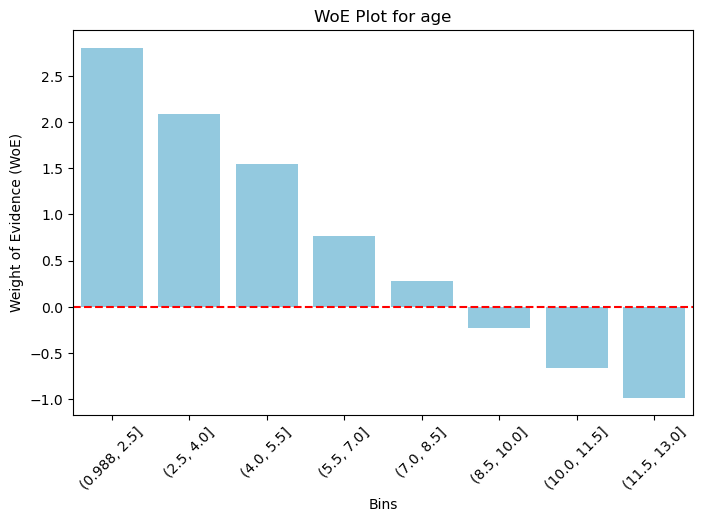

In [34]:
woe_table, iv_bmi = calc_woe_iv(df, feature="age", target="result", bins=8, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "age")

In [39]:
df['age:1_2'] =  np.where((df['age'] >= 1) & (df['age'] < 2), 1, 0)
df['age:2_4'] =  np.where((df['age'] > 2) & (df['age'] <= 4), 1, 0)
df['age:5'] =  np.where((df['age'] == 5), 1, 0)
df['age:5_7'] =  np.where((df['age'] > 5) & (df['age'] <= 7), 1, 0)
df['age:8'] =  np.where((df['age'] == 8), 1, 0)
df['age:8_10'] =  np.where((df['age'] > 8) & (df['age'] <= 10), 1, 0)
df['age:11'] =  np.where((df['age'] == 11), 1, 0)
df['age:11_13'] =  np.where((df['age'] > 11) & (df['age'] <= 13), 1, 0)

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.11215272162357556
              bin   total  events  non_events   %events  %non_events  \
0  (0.995, 1.833]     174      29         145  0.001214     0.000631   
1  (1.833, 2.667]    4043     778        3265  0.032562     0.014209   
2    (2.667, 3.5]    9478    1618        7860  0.067719     0.034206   
3    (3.5, 4.333]   62750    7467       55283  0.312518     0.240584   
4  (4.333, 5.167]   69910    6918       62992  0.289541     0.274132   
5    (5.167, 6.0]  107325    7083      100242  0.296447     0.436239   

        WoE        IV  
0 -0.653369  0.000381  
1 -0.829239  0.015219  
2 -0.682957  0.022888  
3 -0.261594  0.018818  
4 -0.054686  0.000843  
5  0.386321  0.054005  


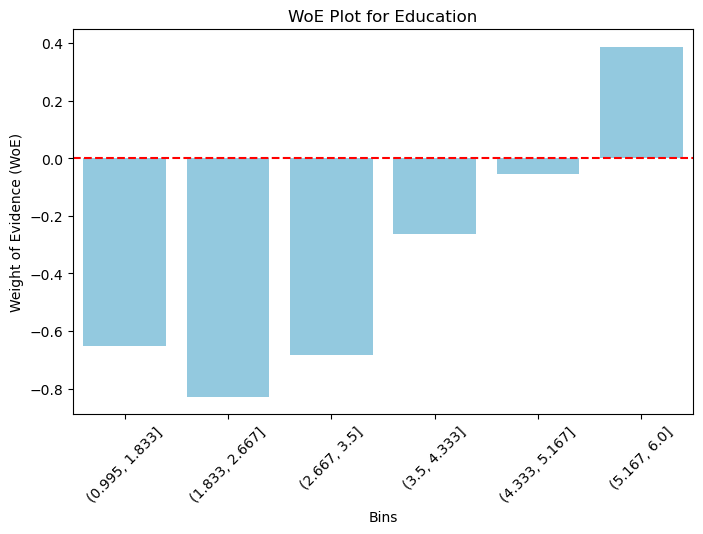

In [44]:
woe_table, iv_bmi = calc_woe_iv(df, feature="education", target="result", bins=6, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "Education")

In [47]:
df['education:1'] = np.where(df['education'] == 1, 1, 0)
df['education:2'] = np.where(df['education'] == 2, 1, 0)
df['education:3'] = np.where(df['education'] == 3, 1, 0)
df['education:4'] = np.where(df['education'] == 4, 1, 0)
df['education:5'] = np.where(df['education'] == 5, 1, 0)
df['education:6'] = np.where(df['education'] == 6, 1, 0)

C:\Users\Ayush\AppData\Local\Temp\ipykernel_16308\3839352146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


Information Value (IV) for BMI: 0.24103606179316162
              bin  total  events  non_events   %events  %non_events       WoE  \
0  (0.993, 1.875]   9811    1553        8258  0.064998     0.035938 -0.592561   
1   (1.875, 2.75]  11783    2197        9586  0.091952     0.041717 -0.790343   
2   (2.75, 3.625]  15994    2519       13475  0.105428     0.058641 -0.586586   
3    (3.625, 4.5]  20135    2828       17307  0.118361     0.075318 -0.452021   
4    (4.5, 5.375]  25883    3161       22722  0.132298     0.098883 -0.291120   
5   (5.375, 6.25]  36470    3646       32824  0.152597     0.142845 -0.066038   
6   (6.25, 7.125]  43219    3404       39815  0.142469     0.173269  0.195724   
7    (7.125, 8.0]  90385    4585       85800  0.191897     0.373389  0.665659   

         IV  
0  0.017220  
1  0.039703  
2  0.027445  
3  0.019457  
4  0.009728  
5  0.000644  
6  0.006028  
7  0.120812  


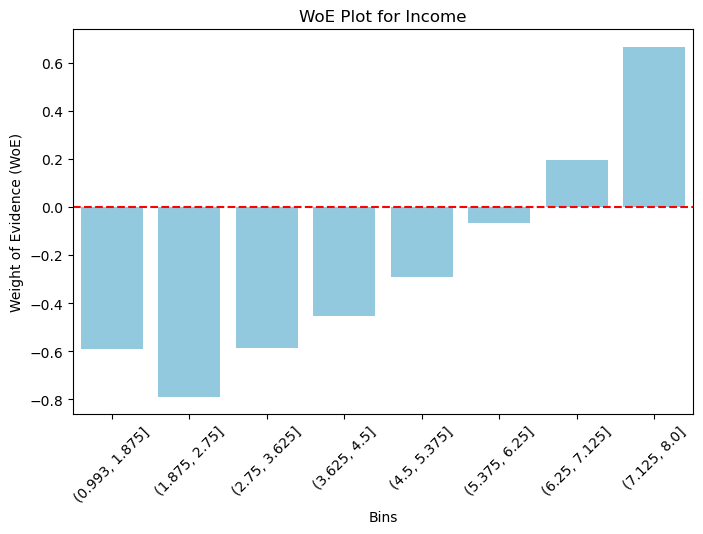

In [46]:
woe_table, iv_bmi = calc_woe_iv(df, feature="income", target="result", bins=8, method="quantil")

print("Information Value (IV) for BMI:", iv_bmi)
print(woe_table)

# Plot WoE to visually check which bins can be merged
plot_woe(woe_table, "Income")

In [48]:
df['income:1'] = np.where(df['income'] == 1, 1, 0)
df['income:2'] = np.where(df['income'] == 2, 1, 0)
df['income:3'] = np.where(df['income'] == 3, 1, 0)
df['income:4'] = np.where(df['income'] == 4, 1, 0)
df['income:5'] = np.where(df['income'] == 5, 1, 0)
df['income:6'] = np.where(df['income'] == 6, 1, 0)
df['income:7'] = np.where(df['income'] == 7, 1, 0)
df['income:8'] = np.where(df['income'] == 8, 1, 0)

In [50]:
for column in df.columns:
    print(column)

result
high_bp
high_chol
chol_check
bmi
smoker
stroke
diabetes
physical_activity
fruits
veggies
heavy_alcoholic
healthcare
no_doc_bc_cost
general_health
mental_health
physical_health
difficult_walking
sex
age
education
income
bin
general_health:1
general_health:2
general_health:3
general_health:4
general_health:5
physical_health:0_3
physical_health:3_9
physical_health:9_15
physical_health:15_24
physical_health:24_30
mental_health:0_9
mental_health:9_12
mental_health:12_15
mental_health:15_21
mental_health:21_24
mental_health:24_27
mental_health:27_30
bmi:11_23
bmi:23_25
bmi:25_27
bmi:27_30
bmi:30_33
bmi:33_98
age:1_2
age:2_4
age:5
age:5_7
age:8
age:8_10
age:11
age:11_13
education:1
education:2
education:3
education:4
education:5
education:6
income:1
income:2
income:3
income:4
income:5
income:6
income:7
income:8


In [57]:
df.drop(columns=['bin', 'general_health', 'physical_health', 'mental_health', 'age', 'income', 'education', 'bmi', 'bmi:25_27', 'general_health:3', 'physical_health:3_9', 'mental_health:0_9', 'age:8_10', 'education:5', 'income:6'], inplace=True)

In [59]:
df.to_csv('processed_heart_disease.csv')